In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import random
import pickle

In [12]:
df_raw = pd.read_csv('salesdaily.csv')
date_col = df_raw.columns[0]
df_raw = df_raw.melt(id_vars=[date_col], var_name='atc_code', value_name='daily_sales')
df_raw['date'] = pd.to_datetime(df_raw[date_col], errors='coerce')
df_raw = df_raw.dropna(subset=['date'])
df_raw['daily_sales'] = pd.to_numeric(df_raw['daily_sales'], errors='coerce').fillna(0)

atc_map = {
    'M01AB': 'Diclofenac', 'M01AE': 'Ibuprofen', 'N02BA': 'Aspirin',
    'N02BE': 'Crocin', 'N05B': 'Alprazolam', 'N05C': 'Sedatives',
    'R03': 'Asthalin', 'R06': 'Cetirizine'
}
df_raw['medicine_name'] = df_raw['atc_code'].map(atc_map)

rows = []
for _, row in df_raw.iterrows():
    base = float(row['daily_sales'])
    past_7 = max(1, int(base * 7 * random.uniform(0.8, 1.2)))
    rows.append({
        'date': row['date'].strftime('%Y-%m-%d'),
        'medicine_name': row['medicine_name'],
        'category': row['atc_code'],
        'past_7_day_sales': past_7,
        'past_30_day_avg_sales': int(base * 30),
        'current_stock': int(past_7 * random.uniform(0.5, 1.5)),
        'days_to_expiry': random.randint(10, 400),
        'price_per_unit': random.randint(15, 350),
        'daily_sales_real': base
    })

store_df = pd.DataFrame(rows)
store_df.to_csv('medstock_store_real.csv', index=False)
print(f'Created {len(store_df)} rows -> medstock_store_real.csv')
store_df.head()

Created 25272 rows -> medstock_store_real.csv


,date,medicine_name,category,past_7_day_sales,past_30_day_avg_sales,current_stock,days_to_expiry,price_per_unit,daily_sales_real
0,2014-01-02,Diclofenac,M01AB,1,0,1,239,233,0.0
1,2014-01-03,Diclofenac,M01AB,50,240,37,249,165,8.0
2,2014-01-04,Diclofenac,M01AB,12,60,11,160,336,2.0
3,2014-01-05,Diclofenac,M01AB,32,120,28,393,64,4.0
4,2014-01-06,Diclofenac,M01AB,29,150,41,363,322,5.0


In [13]:
df = pd.read_csv('medstock_store_real.csv')
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values(['medicine_name', 'date'])

df['past_7_day_sales'] = df.groupby('medicine_name')['daily_sales_real'].transform(
    lambda x: x.shift(1).rolling(7, min_periods=1).sum()
)
df['past_30_day_avg_sales'] = df.groupby('medicine_name')['daily_sales_real'].transform(
    lambda x: x.shift(1).rolling(30, min_periods=1).mean()
)
df['next_7_day_demand'] = df.groupby('medicine_name')['daily_sales_real'].transform(
    lambda x: x.shift(-7).rolling(7, min_periods=1).sum()
)
df['month'] = df['date'].dt.month
df = df.dropna(subset=['past_7_day_sales', 'past_30_day_avg_sales', 'next_7_day_demand'])

live = pd.read_csv('live_data.csv').iloc[-1]
df['live_temp']     = live['live_temp']
df['live_humidity'] = live['live_humidity']
df['is_rainy']      = live['is_rainy']
df['fever_trend']   = live['fever_trend']
df['allergy_trend'] = live['allergy_trend']

df.to_csv('FINAL_TRAINING_DATA_NO_LEAKAGE.csv', index=False)
print(f'Clean dataset: {len(df)} rows')
df[['date','medicine_name','past_7_day_sales','next_7_day_demand']].head()

Clean dataset: 16832 rows


,date,medicine_name,past_7_day_sales,next_7_day_demand
8425,2014-01-03,Alprazolam,7.0,31.0
8426,2014-01-04,Alprazolam,23.0,45.0
8427,2014-01-05,Alprazolam,33.0,53.0
8428,2014-01-06,Alprazolam,41.0,62.0
8429,2014-01-07,Alprazolam,57.0,68.0


In [14]:
df = pd.read_csv('FINAL_TRAINING_DATA_NO_LEAKAGE.csv')
print(df.shape)
df.head()

(16832, 16)


,date,medicine_name,category,past_7_day_sales,past_30_day_avg_sales,current_stock,days_to_expiry,price_per_unit,daily_sales_real,next_7_day_demand,month,live_temp,live_humidity,is_rainy,fever_trend,allergy_trend
0,2014-01-03,Alprazolam,N05B,7.0,7.00,107,358,269,16.0,31.0,1,26.92,83,0,56,0
1,2014-01-04,Alprazolam,N05B,23.0,11.50,91,369,58,10.0,45.0,1,26.92,83,0,56,0
2,2014-01-05,Alprazolam,N05B,33.0,11.00,68,157,17,8.0,53.0,1,26.92,83,0,56,0
3,2014-01-06,Alprazolam,N05B,41.0,10.25,66,49,219,16.0,62.0,1,26.92,83,0,56,0
4,2014-01-07,Alprazolam,N05B,57.0,11.40,0,377,192,0.0,68.0,1,26.92,83,0,56,0


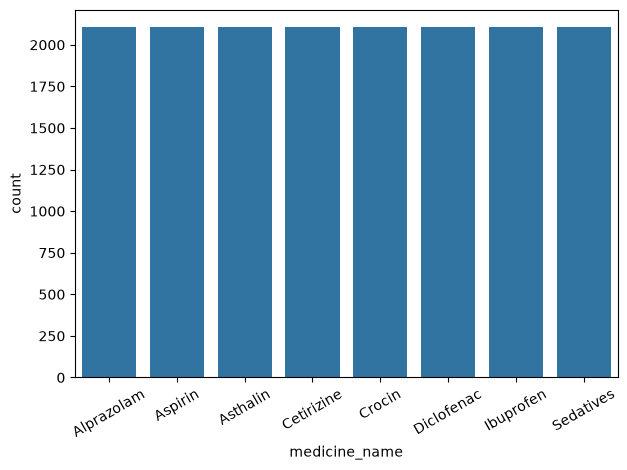

In [15]:
sns.countplot(data=df, x='medicine_name')
plt.xticks(rotation=30)
plt.tight_layout()

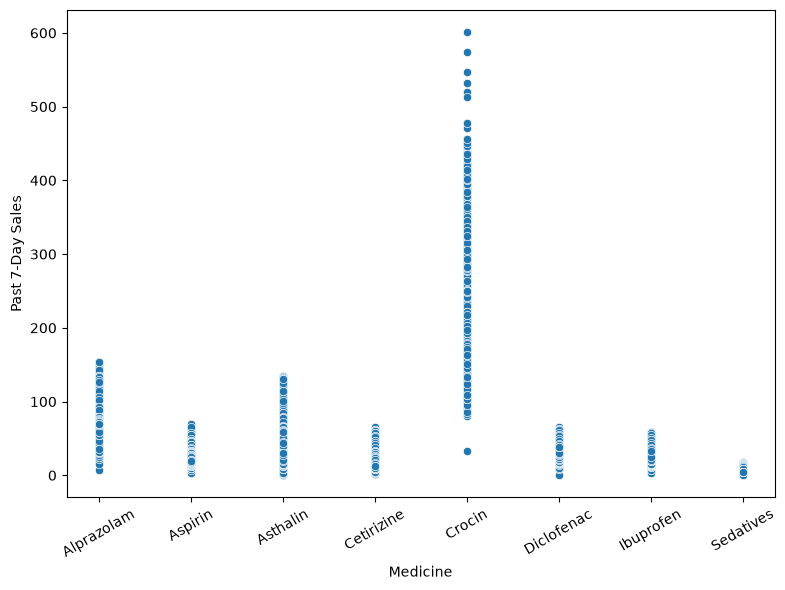

In [16]:
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df, x='medicine_name', y='past_7_day_sales')
plt.xlabel('Medicine')
plt.ylabel('Past 7-Day Sales')
plt.xticks(rotation=30)
plt.tight_layout()

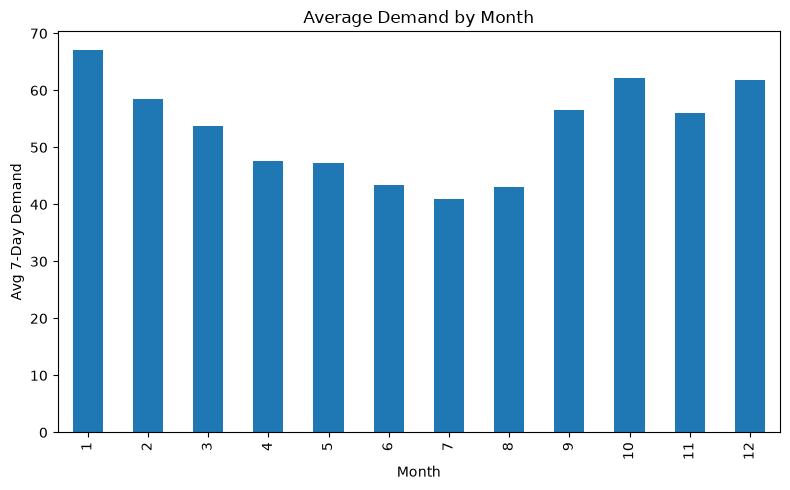

In [17]:
df['month'] = pd.to_datetime(df['date']).dt.month
df.groupby('month')['next_7_day_demand'].mean().plot(kind='bar', figsize=(8,5))
plt.xlabel('Month')
plt.ylabel('Avg 7-Day Demand')
plt.title('Average Demand by Month')
plt.tight_layout()

In [25]:

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score


FEATURE_COLS = [
    'past_7_day_sales', 'past_30_day_avg_sales', 'current_stock',
    'days_to_expiry', 'price_per_unit', 'live_temp', 'live_humidity',
    'is_rainy', 'fever_trend', 'allergy_trend', 'month'
]
TARGET = 'next_7_day_demand'



df = pd.read_csv('FINAL_TRAINING_DATA_NO_LEAKAGE.csv')
df['month'] = pd.to_datetime(df['date']).dt.month
df = df.dropna(subset=FEATURE_COLS + [TARGET])

X = df[FEATURE_COLS]
y = df[TARGET]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.15, random_state=42)

model = RandomForestRegressor(
    n_estimators=200, max_depth=12, min_samples_leaf=10,
    n_jobs=-1, random_state=42
)
model.fit(X_train, y_train)
print(f'Train size: {len(X_train)}  Test size: {len(X_test)}')

Train size: 14307  Test size: 2525


In [26]:
pred = model.predict(X_test)
print(f'MAE : {mean_absolute_error(y_test, pred):.2f} units')
print(f'R²  : {r2_score(y_test, pred):.4f}')
print(f'Train R²: {model.score(X_train, y_train):.4f}')

MAE : 9.72 units
R²  : 0.9322
Train R²: 0.9534


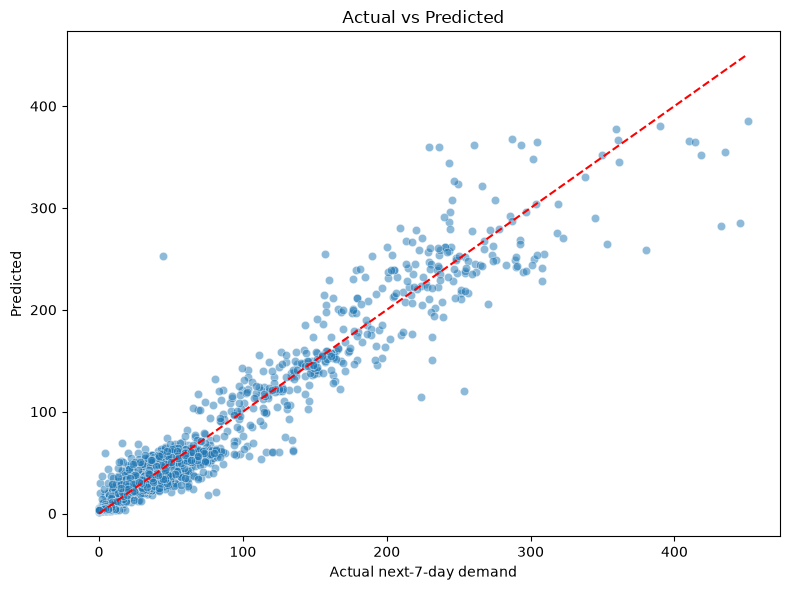

In [27]:
plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_test, y=pred, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel('Actual next-7-day demand')
plt.ylabel('Predicted')
plt.title('Actual vs Predicted')
plt.tight_layout()

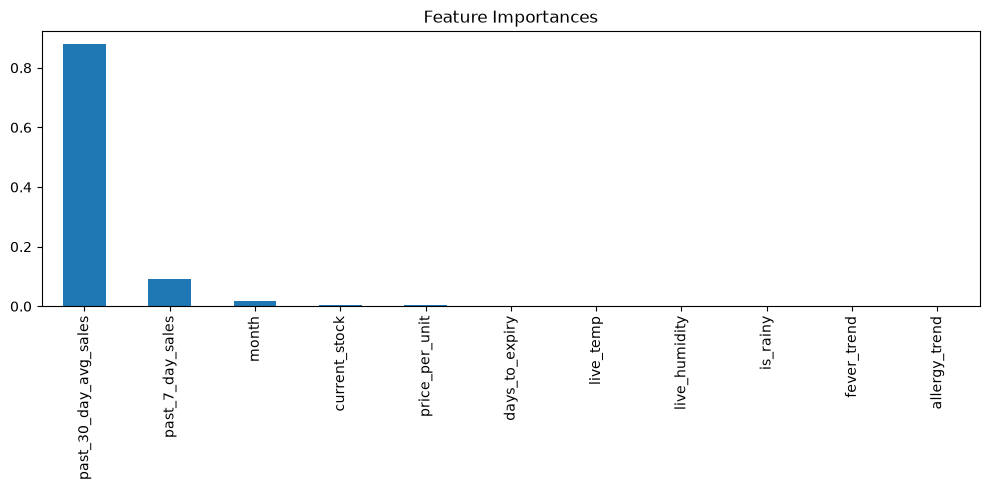

In [28]:
feat_imp = pd.Series(model.feature_importances_, index=FEATURE_COLS).sort_values(ascending=False)
feat_imp.plot(kind='bar', figsize=(10, 5), title='Feature Importances')
plt.tight_layout()

In [ ]:
pickle.dump(model, open('model_rf.pkl', 'wb'))
print('model_rf.pkl saved')

model_rf.pkl saved
Feature order for API: ['past_7_day_sales', 'past_30_day_avg_sales', 'current_stock', 'days_to_expiry', 'price_per_unit', 'live_temp', 'live_humidity', 'is_rainy', 'fever_trend', 'allergy_trend', 'month']
